# Week 5 — Day 3 : Statistics for Machine Learning
## Inferential Statistics, Hypothesis Testing, A/B Testing & Bootstrapping

**Student :** Leeroy Benaich  
**Bootcamp :** GenAI & Machine Learning — 2026

---
### Plan
1. Setup & Data Generation
2. Inferential Statistics — p-values & Confidence Intervals
3. Hypothesis Testing — t-test vs z-test
4. A/B Testing for Model Comparison
5. Bootstrapping for Model Stability
6. Summary & Insights

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)

print('Libraries imported ✓')

Libraries imported ✓


---
## 1. Inferential Statistics — p-values & Confidence Intervals

**Inferential statistics** = tirer des conclusions sur une **population** à partir d'un **échantillon**.

### Concepts clés
| Concept | Définition |
|---|---|
| **H₀ (hypothèse nulle)** | Pas d'effet, pas de différence — c'est ce qu'on cherche à réfuter |
| **H₁ (hypothèse alternative)** | Il existe un effet ou une différence |
| **p-value** | Probabilité d'observer les données si H₀ est vraie. p < 0.05 → on rejette H₀ |
| **Intervalle de confiance** | Plage de valeurs qui contient le vrai paramètre avec une certaine probabilité (ex: 95%) |

In [2]:
# ── Simulation : scores de deux modèles ML ───────────────────────────
# Modèle A : accuracy moyenne 82%, Modèle B : accuracy moyenne 85%
n_experiments = 30
model_A_scores = np.random.normal(loc=0.82, scale=0.03, size=n_experiments)
model_B_scores = np.random.normal(loc=0.85, scale=0.03, size=n_experiments)

print('=== Statistiques descriptives ===')
print(f'Modèle A — Moyenne : {model_A_scores.mean():.4f} | Std : {model_A_scores.std():.4f}')
print(f'Modèle B — Moyenne : {model_B_scores.mean():.4f} | Std : {model_B_scores.std():.4f}')

# ── Intervalle de confiance à 95% ────────────────────────────────────
def confidence_interval_95(data):
    n    = len(data)
    mean = np.mean(data)
    se   = stats.sem(data)          # erreur standard
    ci   = stats.t.ppf(0.975, df=n-1) * se  # t critique à 95%
    return mean - ci, mean + ci

ci_A = confidence_interval_95(model_A_scores)
ci_B = confidence_interval_95(model_B_scores)

print(f'\nIC 95% Modèle A : [{ci_A[0]:.4f}, {ci_A[1]:.4f}]')
print(f'IC 95% Modèle B : [{ci_B[0]:.4f}, {ci_B[1]:.4f}]')
print('\n→ Si les IC ne se chevauchent pas, la différence est probablement significative.')

=== Statistiques descriptives ===
Modèle A — Moyenne : 0.8144 | Std : 0.0265
Modèle B — Moyenne : 0.8464 | Std : 0.0275

IC 95% Modèle A : [0.8043, 0.8244]
IC 95% Modèle B : [0.8359, 0.8568]

→ Si les IC ne se chevauchent pas, la différence est probablement significative.


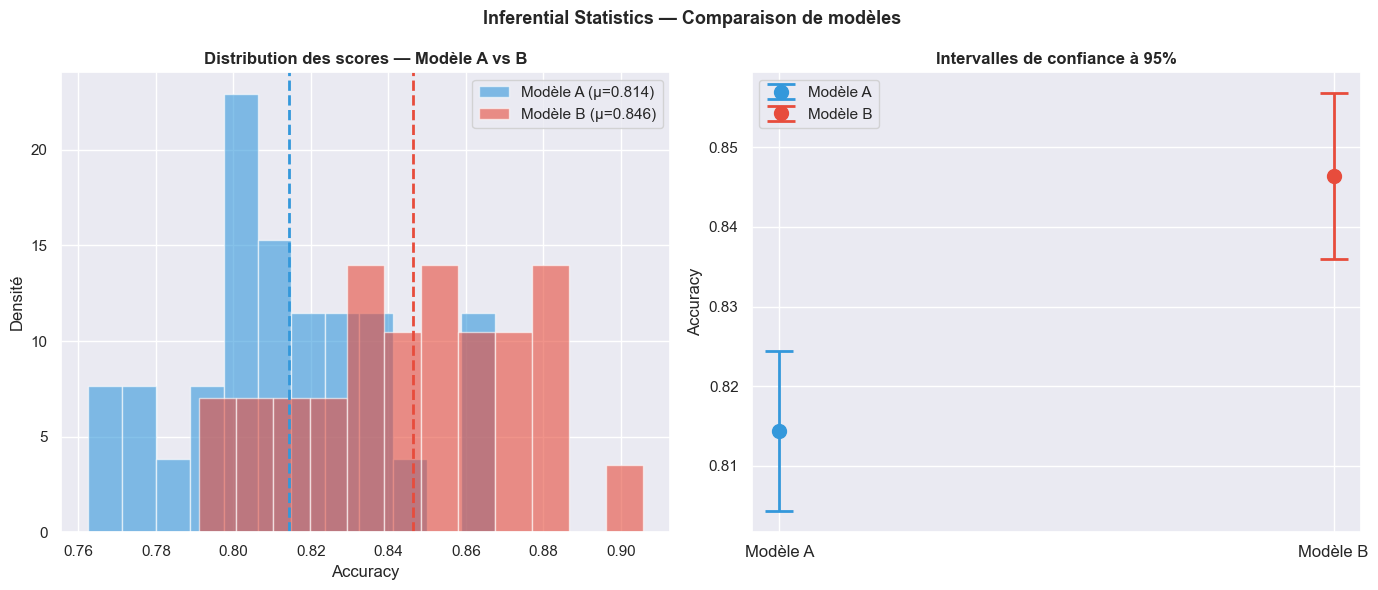

In [3]:
# Visualisation des distributions et intervalles de confiance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution des scores
axes[0].hist(model_A_scores, bins=12, alpha=0.6, color='#3498db',
             label=f'Modèle A (μ={model_A_scores.mean():.3f})', density=True)
axes[0].hist(model_B_scores, bins=12, alpha=0.6, color='#e74c3c',
             label=f'Modèle B (μ={model_B_scores.mean():.3f})', density=True)
axes[0].axvline(model_A_scores.mean(), color='#3498db', linewidth=2, linestyle='--')
axes[0].axvline(model_B_scores.mean(), color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Distribution des scores — Modèle A vs B', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].set_ylabel('Densité')
axes[0].legend()

# Intervalles de confiance
models_labels = ['Modèle A', 'Modèle B']
means = [model_A_scores.mean(), model_B_scores.mean()]
cis   = [ci_A, ci_B]
colors_ci = ['#3498db', '#e74c3c']

for i, (label, mean, ci, color) in enumerate(zip(models_labels, means, cis, colors_ci)):
    axes[1].errorbar(i, mean, yerr=[[mean - ci[0]], [ci[1] - mean]],
                     fmt='o', color=color, capsize=10, capthick=2,
                     markersize=10, linewidth=2, label=label)

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(models_labels, fontsize=12)
axes[1].set_title('Intervalles de confiance à 95%', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Inferential Statistics — Comparaison de modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot1_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Hypothesis Testing — t-test vs z-test

| Test | Quand l'utiliser | Condition |
|---|---|---|
| **t-test** | Petit échantillon (n < 30) OU écart-type inconnu | Distribution t de Student |
| **z-test** | Grand échantillon (n ≥ 30) ET écart-type connu | Distribution normale |
| **t-test apparié** | Même groupe mesuré deux fois (avant/après) | Données dépendantes |
| **t-test indépendant** | Deux groupes différents | Données indépendantes |

In [4]:
# ── t-test indépendant : Modèle A vs Modèle B ────────────────────────
t_stat, p_value = stats.ttest_ind(model_A_scores, model_B_scores)

print('=== t-test indépendant (Modèle A vs Modèle B) ===')
print(f'H₀ : μ_A = μ_B (pas de différence significative)')
print(f'H₁ : μ_A ≠ μ_B')
print(f'\nStatistique t : {t_stat:.4f}')
print(f'p-value       : {p_value:.6f}')
print(f'Seuil α       : 0.05')
print(f'\nConclusion : H₀ {"REJETÉE ✗" if p_value < 0.05 else "NON rejetée ✓"}')
if p_value < 0.05:
    print('→ La différence entre les deux modèles est statistiquement significative.')
    print(f'→ Le Modèle B est significativement meilleur que le Modèle A.')

=== t-test indépendant (Modèle A vs Modèle B) ===
H₀ : μ_A = μ_B (pas de différence significative)
H₁ : μ_A ≠ μ_B

Statistique t : -4.5129
p-value       : 0.000032
Seuil α       : 0.05

Conclusion : H₀ REJETÉE ✗
→ La différence entre les deux modèles est statistiquement significative.
→ Le Modèle B est significativement meilleur que le Modèle A.


In [5]:
# ── t-test apparié : avant/après tuning ──────────────────────────────
before_tuning = np.random.normal(0.80, 0.025, 25)
after_tuning  = before_tuning + np.random.normal(0.03, 0.015, 25)  # amélioration après tuning

t_paired, p_paired = stats.ttest_rel(before_tuning, after_tuning)

print('=== t-test apparié : avant vs après hyperparameter tuning ===')
print(f'Moyenne avant tuning : {before_tuning.mean():.4f}')
print(f'Moyenne après tuning : {after_tuning.mean():.4f}')
print(f'Gain moyen           : +{(after_tuning - before_tuning).mean():.4f}')
print(f'\nStatistique t : {t_paired:.4f}')
print(f'p-value       : {p_paired:.6f}')
print(f'\nConclusion : Le tuning {"améliore significativement" if p_paired < 0.05 else "n'améliore pas significativement"} les performances (α=0.05)')

# ── z-test : grand échantillon ────────────────────────────────────────
# Quand n >= 30, on peut utiliser une approximation z
from scipy.stats import norm

n = len(model_A_scores)
diff_mean = model_B_scores.mean() - model_A_scores.mean()
pooled_std = np.sqrt((model_A_scores.std()**2 + model_B_scores.std()**2) / n)
z_stat = diff_mean / pooled_std
p_z = 2 * (1 - norm.cdf(abs(z_stat)))

print(f'\n=== z-test (grand échantillon, n={n}) ===')
print(f'z-statistic : {z_stat:.4f}')
print(f'p-value     : {p_z:.6f}')
print(f'Conclusion  : H₀ {"REJETÉE" if p_z < 0.05 else "non rejetée"} — résultat cohérent avec le t-test')

=== t-test apparié : avant vs après hyperparameter tuning ===
Moyenne avant tuning : 0.7997
Moyenne après tuning : 0.8289
Gain moyen           : +0.0292

Statistique t : -13.4945
p-value       : 0.000000

Conclusion : Le tuning améliore significativement les performances (α=0.05)

=== z-test (grand échantillon, n=30) ===
z-statistic : 4.5901
p-value     : 0.000004
Conclusion  : H₀ REJETÉE — résultat cohérent avec le t-test


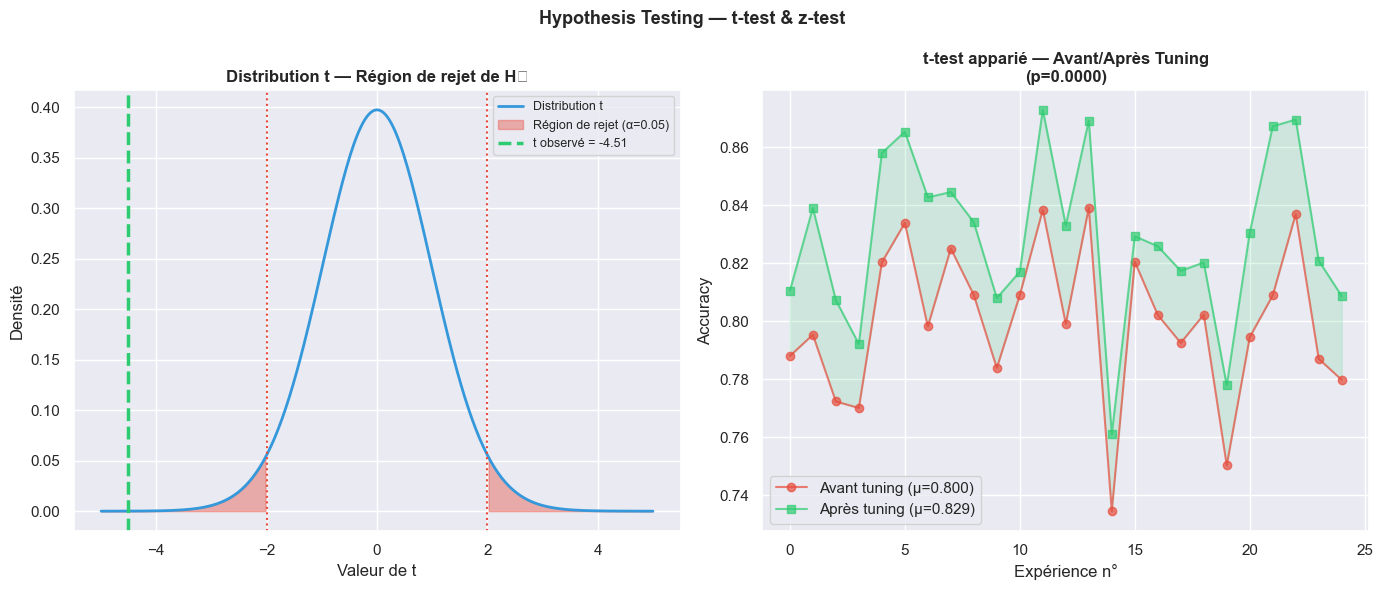

In [6]:
# Visualisation : p-value et région de rejet
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution t et région de rejet
df_t = 2 * n_experiments - 2
x = np.linspace(-5, 5, 300)
y = stats.t.pdf(x, df=df_t)
t_crit = stats.t.ppf(0.975, df=df_t)

axes[0].plot(x, y, color='#3498db', linewidth=2, label='Distribution t')
axes[0].fill_between(x, y, where=x < -t_crit, alpha=0.4, color='#e74c3c', label='Région de rejet (α=0.05)')
axes[0].fill_between(x, y, where=x > t_crit, alpha=0.4, color='#e74c3c')
axes[0].axvline(t_stat, color='#2ecc71', linewidth=2.5, linestyle='--',
                label=f't observé = {t_stat:.2f}')
axes[0].axvline(-t_crit, color='#e74c3c', linewidth=1.5, linestyle=':')
axes[0].axvline(t_crit, color='#e74c3c', linewidth=1.5, linestyle=':')
axes[0].set_title('Distribution t — Région de rejet de H₀', fontweight='bold')
axes[0].set_xlabel('Valeur de t')
axes[0].set_ylabel('Densité')
axes[0].legend(fontsize=9)

# Avant / Après tuning
axes[1].plot(range(25), before_tuning, 'o-', color='#e74c3c', alpha=0.7,
             label=f'Avant tuning (μ={before_tuning.mean():.3f})', linewidth=1.5)
axes[1].plot(range(25), after_tuning, 's-', color='#2ecc71', alpha=0.7,
             label=f'Après tuning (μ={after_tuning.mean():.3f})', linewidth=1.5)
axes[1].fill_between(range(25), before_tuning, after_tuning, alpha=0.15, color='#2ecc71')
axes[1].set_title(f't-test apparié — Avant/Après Tuning\n(p={p_paired:.4f})', fontweight='bold')
axes[1].set_xlabel('Expérience n°')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.suptitle('Hypothesis Testing — t-test & z-test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_hypothesis_testing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. A/B Testing for Model Comparison

L'**A/B testing** est une méthode pour comparer deux versions (A et B) et déterminer statistiquement laquelle est meilleure.

En ML, on l'utilise pour :
- Comparer deux modèles déployés en production
- Valider qu'un nouveau modèle est réellement meilleur avant de remplacer l'ancien
- Tester l'impact d'une feature sur les performances

In [7]:
# ── Chargement du dataset Breast Cancer ──────────────────────────────
data = load_breast_cancer()
X, y = data.data, data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

print(f'Dataset : {X.shape[0]} échantillons, {X.shape[1]} features')
print(f'Train : {X_train.shape[0]} | Test : {X_test.shape[0]}')

# ── Modèle A (contrôle) vs Modèle B (challenger) ─────────────────────
model_A = LogisticRegression(random_state=42, max_iter=1000)    # Modèle actuel
model_B = RandomForestClassifier(n_estimators=100, random_state=42)  # Nouveau modèle

# Simuler un A/B test : 50 splits aléatoires
n_splits = 50
scores_A, scores_B = [], []

for seed in range(n_splits):
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_scaled, y, test_size=0.2, random_state=seed)
    model_A.fit(X_tr, y_tr)
    model_B.fit(X_tr, y_tr)
    scores_A.append(accuracy_score(y_te, model_A.predict(X_te)))
    scores_B.append(accuracy_score(y_te, model_B.predict(X_te)))

scores_A = np.array(scores_A)
scores_B = np.array(scores_B)

print(f'\nModèle A (Logistic Regression) — Moyenne : {scores_A.mean():.4f} ± {scores_A.std():.4f}')
print(f'Modèle B (Random Forest)       — Moyenne : {scores_B.mean():.4f} ± {scores_B.std():.4f}')

# Test statistique
t_ab, p_ab = stats.ttest_rel(scores_A, scores_B)
print(f'\n=== A/B Test (t-test apparié sur {n_splits} splits) ===')
print(f'p-value : {p_ab:.6f}')
print(f'Conclusion : Modèle B est {"significativement" if p_ab < 0.05 else "PAS significativement"} meilleur que Modèle A (α=0.05)')

Dataset : 569 échantillons, 30 features
Train : 455 | Test : 114



Modèle A (Logistic Regression) — Moyenne : 0.9777 ± 0.0114
Modèle B (Random Forest)       — Moyenne : 0.9584 ± 0.0178

=== A/B Test (t-test apparié sur 50 splits) ===
p-value : 0.000000
Conclusion : Modèle B est significativement meilleur que Modèle A (α=0.05)


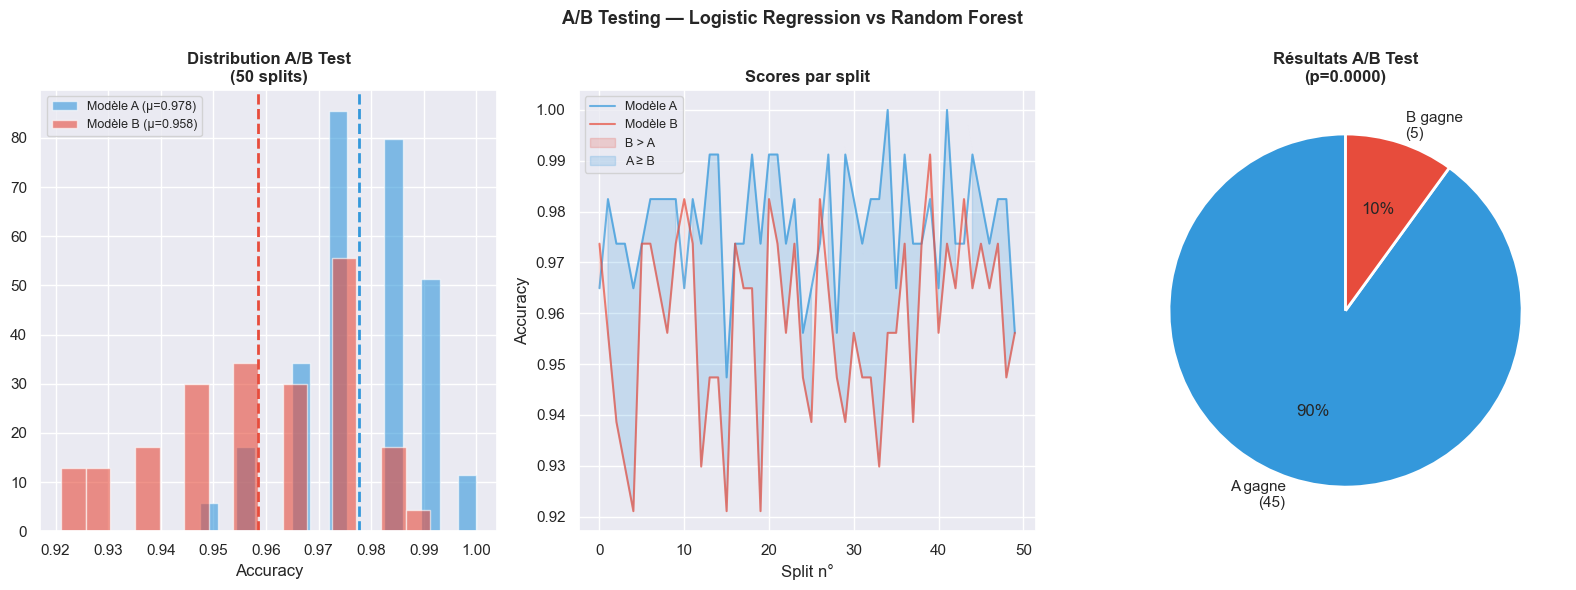

In [8]:
# Visualisation A/B Test
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Distribution des scores A/B
axes[0].hist(scores_A, bins=15, alpha=0.6, color='#3498db',
             label=f'Modèle A (μ={scores_A.mean():.3f})', density=True)
axes[0].hist(scores_B, bins=15, alpha=0.6, color='#e74c3c',
             label=f'Modèle B (μ={scores_B.mean():.3f})', density=True)
axes[0].axvline(scores_A.mean(), color='#3498db', linewidth=2, linestyle='--')
axes[0].axvline(scores_B.mean(), color='#e74c3c', linewidth=2, linestyle='--')
axes[0].set_title('Distribution A/B Test\n(50 splits)', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].legend(fontsize=9)

# Évolution des scores par split
axes[1].plot(scores_A, color='#3498db', alpha=0.7, linewidth=1.5, label='Modèle A')
axes[1].plot(scores_B, color='#e74c3c', alpha=0.7, linewidth=1.5, label='Modèle B')
axes[1].fill_between(range(n_splits), scores_A, scores_B,
                     where=scores_B > scores_A, alpha=0.2, color='#e74c3c', label='B > A')
axes[1].fill_between(range(n_splits), scores_A, scores_B,
                     where=scores_A >= scores_B, alpha=0.2, color='#3498db', label='A ≥ B')
axes[1].set_title('Scores par split', fontweight='bold')
axes[1].set_xlabel('Split n°')
axes[1].set_ylabel('Accuracy')
axes[1].legend(fontsize=9)

# Victoires A vs B
wins_B = (scores_B > scores_A).sum()
wins_A = n_splits - wins_B
axes[2].pie([wins_A, wins_B], labels=[f'A gagne\n({wins_A})', f'B gagne\n({wins_B})'],
            colors=['#3498db', '#e74c3c'], autopct='%1.0f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
axes[2].set_title(f'Résultats A/B Test\n(p={p_ab:.4f})', fontweight='bold')

plt.suptitle('A/B Testing — Logistic Regression vs Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot3_ab_testing.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Bootstrapping for Model Stability

Le **bootstrapping** consiste à ré-échantillonner les données **avec remise** pour estimer la distribution d'une statistique.

En ML, il permet de :
- Estimer l'incertitude des performances d'un modèle
- Calculer des intervalles de confiance sans hypothèse distributionnelle
- Évaluer la stabilité d'un modèle

In [9]:
# ── Bootstrapping : estimer la distribution de l'accuracy ────────────
def bootstrap_accuracy(model, X, y, n_iterations=1000, sample_size=0.8):
    """Calcule n_iterations scores en rééchantillonnant avec remise."""
    boot_scores = []
    n = len(y)
    for _ in range(n_iterations):
        # Tirage avec remise
        indices = np.random.choice(n, size=int(n * sample_size), replace=True)
        out_of_bag = np.setdiff1d(np.arange(n), indices)  # échantillons non tirés
        if len(out_of_bag) == 0:
            continue
        model.fit(X[indices], y[indices])
        score = accuracy_score(y[out_of_bag], model.predict(X[out_of_bag]))
        boot_scores.append(score)
    return np.array(boot_scores)

print('Bootstrapping en cours (1000 itérations × 3 modèles)...')

boot_lr  = bootstrap_accuracy(LogisticRegression(max_iter=1000), X_scaled, y, n_iterations=500)
boot_rf  = bootstrap_accuracy(RandomForestClassifier(n_estimators=50, random_state=42), X_scaled, y, n_iterations=500)
boot_gb  = bootstrap_accuracy(GradientBoostingClassifier(n_estimators=50, random_state=42), X_scaled, y, n_iterations=500)

print('\n=== Résultats Bootstrap (500 itérations) ===')
for name, scores in [('Logistic Regression', boot_lr),
                     ('Random Forest', boot_rf),
                     ('Gradient Boosting', boot_gb)]:
    ci_low  = np.percentile(scores, 2.5)
    ci_high = np.percentile(scores, 97.5)
    print(f'{name:<22} : μ={scores.mean():.4f} | IC95%=[{ci_low:.4f}, {ci_high:.4f}] | Std={scores.std():.4f}')

Bootstrapping en cours (1000 itérations × 3 modèles)...



=== Résultats Bootstrap (500 itérations) ===
Logistic Regression    : μ=0.9732 | IC95%=[0.9543, 0.9885] | Std=0.0091
Random Forest          : μ=0.9552 | IC95%=[0.9301, 0.9770] | Std=0.0121
Gradient Boosting      : μ=0.9485 | IC95%=[0.9175, 0.9731] | Std=0.0144


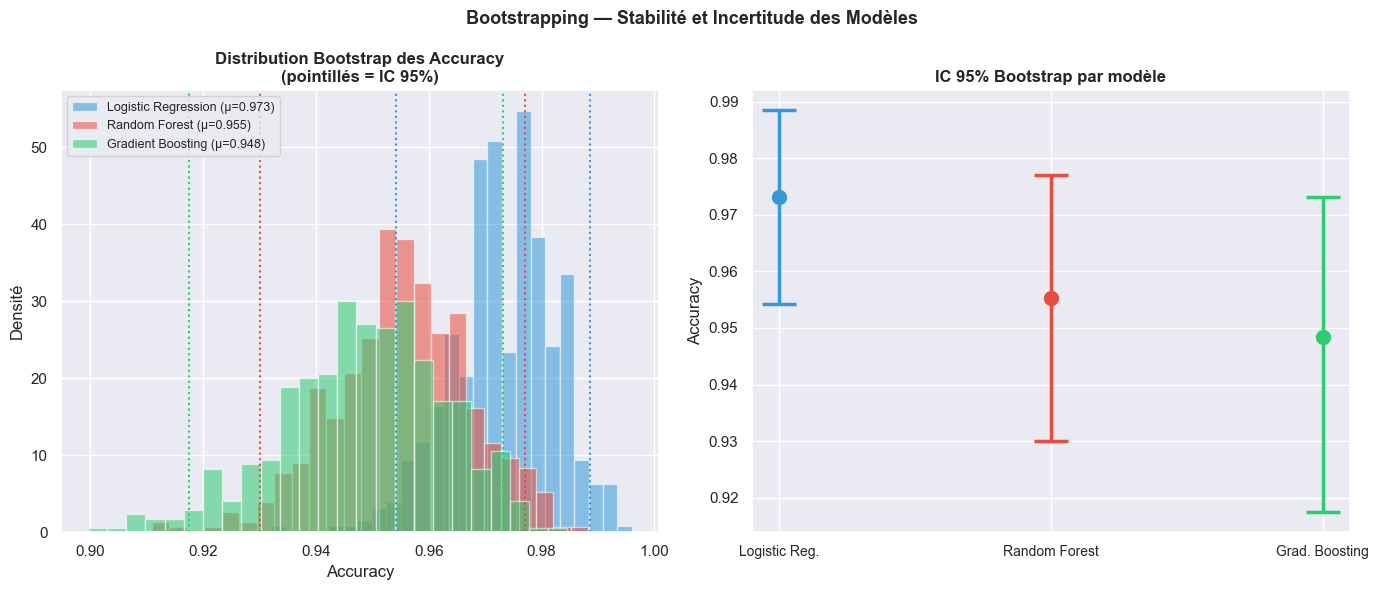

In [10]:
# Visualisation bootstrap
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribution bootstrap
for scores, label, color in [
    (boot_lr, 'Logistic Regression', '#3498db'),
    (boot_rf, 'Random Forest',       '#e74c3c'),
    (boot_gb, 'Gradient Boosting',   '#2ecc71')
]:
    axes[0].hist(scores, bins=25, alpha=0.55, color=color,
                 label=f'{label} (μ={scores.mean():.3f})', density=True)
    axes[0].axvline(np.percentile(scores, 2.5),  color=color, linewidth=1.5, linestyle=':')
    axes[0].axvline(np.percentile(scores, 97.5), color=color, linewidth=1.5, linestyle=':')

axes[0].set_title('Distribution Bootstrap des Accuracy\n(pointillés = IC 95%)', fontweight='bold')
axes[0].set_xlabel('Accuracy')
axes[0].set_ylabel('Densité')
axes[0].legend(fontsize=9)

# Intervalles de confiance bootstrap
boot_data = [
    ('LR', boot_lr,  '#3498db'),
    ('RF', boot_rf,  '#e74c3c'),
    ('GB', boot_gb,  '#2ecc71'),
]
for i, (label, scores, color) in enumerate(boot_data):
    mean   = scores.mean()
    ci_low = np.percentile(scores, 2.5)
    ci_high = np.percentile(scores, 97.5)
    axes[1].errorbar(i, mean,
                     yerr=[[mean - ci_low], [ci_high - mean]],
                     fmt='o', color=color, capsize=12, capthick=2.5,
                     markersize=10, linewidth=2.5, label=label)

axes[1].set_xticks([0, 1, 2])
axes[1].set_xticklabels(['Logistic Reg.', 'Random Forest', 'Grad. Boosting'], fontsize=10)
axes[1].set_title('IC 95% Bootstrap par modèle', fontweight='bold')
axes[1].set_ylabel('Accuracy')

plt.suptitle('Bootstrapping — Stabilité et Incertitude des Modèles', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_bootstrapping.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. F-Statistic & ANOVA — Comparer 3+ modèles

Quand on compare **plus de 2 modèles**, on utilise l'**ANOVA** (Analysis of Variance) via la F-statistic.  
H₀ : tous les modèles ont la même performance moyenne.

In [11]:
# Cross-validation scores pour 3 modèles
models_cv = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X_scaled, y, cv=10, scoring='accuracy')
    cv_results[name] = scores
    print(f'{name:<22} : μ={scores.mean():.4f} | Std={scores.std():.4f}')

# ANOVA (F-test)
f_stat, p_anova = stats.f_oneway(*cv_results.values())

print(f'\n=== ANOVA (F-test) — 3 modèles ===')
print(f'F-statistic : {f_stat:.4f}')
print(f'p-value     : {p_anova:.6f}')
print(f'\nConclusion : Il {"existe" if p_anova < 0.05 else "n'existe pas"} une différence significative entre les 3 modèles (α=0.05)')

Logistic Regression    : μ=0.9807 | Std=0.0146


Random Forest          : μ=0.9632 | Std=0.0308


Gradient Boosting      : μ=0.9614 | Std=0.0291

=== ANOVA (F-test) — 3 modèles ===
F-statistic : 1.5224
p-value     : 0.236324

Conclusion : Il n'existe pas une différence significative entre les 3 modèles (α=0.05)


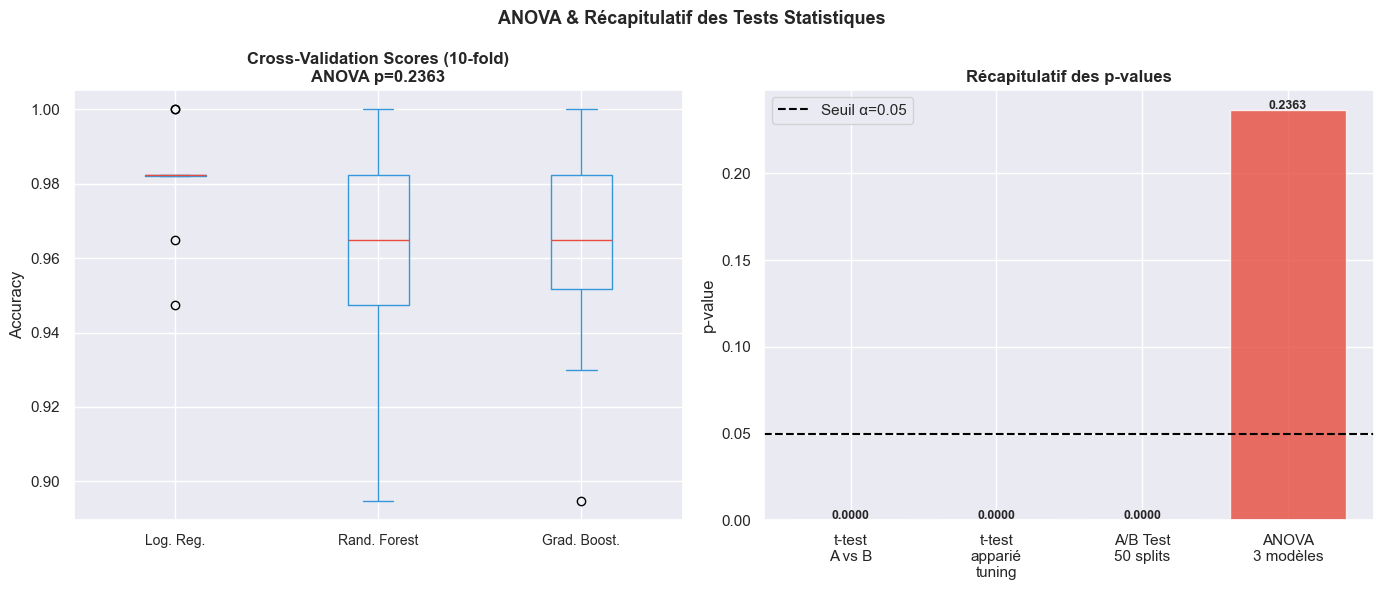

In [12]:
# Visualisation ANOVA + résumé final
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot des CV scores
cv_df = pd.DataFrame(cv_results)
cv_df.boxplot(ax=axes[0], color={'boxes':'#3498db','whiskers':'#3498db',
                                  'caps':'#3498db','medians':'#e74c3c'})
axes[0].set_title(f'Cross-Validation Scores (10-fold)\nANOVA p={p_anova:.4f}', fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticklabels(['Log. Reg.', 'Rand. Forest', 'Grad. Boost.'], fontsize=10)

# Récapitulatif p-values
tests = ['t-test\nA vs B', 't-test\napparié\ntuning', 'A/B Test\n50 splits', 'ANOVA\n3 modèles']
pvals = [p_value, p_paired, p_ab, p_anova]
colors_p = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in pvals]
bars = axes[1].bar(tests, pvals, color=colors_p, alpha=0.8, edgecolor='white')
axes[1].axhline(0.05, color='black', linestyle='--', linewidth=1.5, label='Seuil α=0.05')
axes[1].set_title('Récapitulatif des p-values', fontweight='bold')
axes[1].set_ylabel('p-value')
axes[1].legend()
for bar, p in zip(bars, pvals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{p:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('ANOVA & Récapitulatif des Tests Statistiques', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_anova_summary.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Summary & Insights

| Technique | Quand l'utiliser | Ce qu'elle mesure |
|---|---|---|
| **t-test indépendant** | Comparer 2 groupes différents | Différence de moyennes entre 2 modèles |
| **t-test apparié** | Avant/après sur le même dataset | Impact d'une amélioration (tuning, feature) |
| **z-test** | Grand échantillon (n≥30), σ connu | Différence de moyennes avec grande précision |
| **A/B Testing** | Comparer 2 modèles en production | Lequel est réellement meilleur sur de multiples runs |
| **Bootstrapping** | Quantifier l'incertitude du modèle | Stabilité et IC sans hypothèse distributionnelle |
| **ANOVA (F-test)** | Comparer 3+ modèles | Existe-t-il une différence significative entre les groupes |

### Règles clés
- **p < 0.05** → On rejette H₀ (la différence est statistiquement significative)
- **p ≥ 0.05** → On ne peut pas rejeter H₀ (pas de preuve suffisante)
- **IC 95% qui ne se chevauchent pas** → différence significative
- **Bootstrapping** = la méthode la plus fiable quand les hypothèses paramétriques ne sont pas vérifiées
- Toujours utiliser le **t-test apparié** plutôt qu'indépendant quand les modèles sont testés sur les mêmes données